/tmp/ipykernel_13246/1561495634.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ingredient', y='Delta', data=df_data, order=order,
/tmp/ipykernel_13246/1561495634.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontweight='bold', fontsize=16)


Figure successfully saved as Figure_3f.pdf


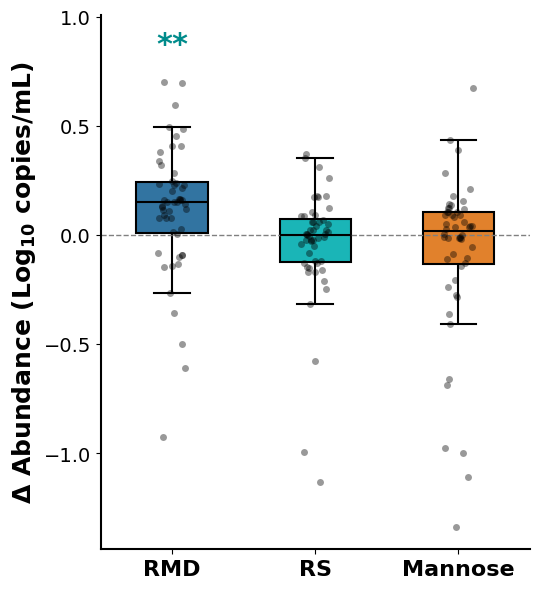

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as multitest
import re

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['mathtext.default'] = 'regular'
DPI_SETTING = 600

strong_palette = {'RMD': '#1f77b4', 'RS': '#00CED1', 'Mannose': '#ff7f0e'}
target_ingredients = ['Resistant maltodextrin', 'Resistant starch', 'Mannose']
name_map = {'Resistant maltodextrin': 'RMD', 'Resistant starch': 'RS', 'Mannose': 'Mannose'}
order = ['RMD', 'RS', 'Mannose']

def get_star(q):
    if q < 0.001: return '***'
    elif q < 0.01: return '**'
    elif q < 0.05: return '*'
    else: return ''

def fix_sci_notation(val):
    if pd.isna(val):
        return val
    s = str(val).strip()
    s = re.sub(r'(\d+\.\d+)\.(E[+-]\d+)', r'\1\2', s)
    return s

def clean_and_convert_strict(vals):
    s_vals = pd.Series(vals).astype(str)
    s_vals = s_vals.replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], np.nan)
    s_vals = s_vals.apply(fix_sci_notation)
    return pd.to_numeric(s_vals, errors='coerce')

df = pd.read_csv('Bacteroides(qPCR).csv')
donor_cols = [c for c in df.columns if c.startswith('HS-')]

ctrl_mask = df['KULFFI'] == 'Control'
ctrl_vals = clean_and_convert_strict(df.loc[ctrl_mask, donor_cols].iloc[0].values)

plot_data = []
p_values_list = []
targets_for_correction = []

for ingredient in target_ingredients:
    mask = df['KULFFI'] == ingredient
    if not mask.any():
        mask = df['KULFFI'].str.contains(ingredient, case=False, na=False)
    if not mask.any(): continue

    treat_vals = clean_and_convert_strict(df.loc[mask, donor_cols].iloc[0].values)

    pair_df = pd.DataFrame({'Ctrl': ctrl_vals, 'Treat': treat_vals}).dropna()
    if len(pair_df) == 0: continue

    c_val = np.log10(pair_df['Ctrl'] + 1)
    t_val = np.log10(pair_df['Treat'] + 1)
    delta = t_val - c_val

    if np.all(delta == 0):
        p = 1.0
    else:
        try:
            stat, p = stats.wilcoxon(t_val, c_val, zero_method='wilcox')
        except ValueError:
            p = 1.0

    p_values_list.append(p)
    targets_for_correction.append(name_map[ingredient])

    for v in delta:
        plot_data.append({'Ingredient': name_map[ingredient], 'Delta': v})

_, q_values, _, _ = multitest.multipletests(p_values_list, alpha=0.05, method='fdr_bh')
q_dict = dict(zip(targets_for_correction, q_values))
df_data = pd.DataFrame(plot_data)

fig, ax = plt.subplots(figsize=(5.5, 6))

sns.boxplot(x='Ingredient', y='Delta', data=df_data, order=order,
            palette=strong_palette, width=0.5, showfliers=False, ax=ax, linewidth=1.5)

for patch in ax.patches:
    patch.set_edgecolor('black')
for line in ax.lines:
    line.set_color('black')

sns.stripplot(x='Ingredient', y='Delta', data=df_data, order=order,
              color='black', alpha=0.4, size=5, jitter=True, ax=ax)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_ylabel(r'$\Delta$ Abundance (Log$_{10}$ copies/mL)', fontsize=18, fontweight='bold')
ax.set_xlabel('')

ax.set_xlim(-0.5, 2.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontweight='bold', fontsize=16)
ax.tick_params(axis='y', labelsize=14)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_linewidth(1.5)

y_range = df_data['Delta'].max() - df_data['Delta'].min()
ax.set_ylim(df_data['Delta'].min() - y_range*0.05, df_data['Delta'].max() + y_range*0.15)

for i, name in enumerate(order):
    if name in q_dict:
        g_max = df_data[df_data['Ingredient']==name]['Delta'].max()
        if q_dict[name] < 0.05:
            ax.text(i, g_max + y_range*0.05, get_star(q_dict[name]),
                    ha='center', va='bottom', fontsize=22, fontweight='bold', color='#008B8B')

plt.tight_layout()

output_file = 'Figure_3f.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight', transparent=True)
print(f"Figure successfully saved as {output_file}")